# View-Based (CC, MLO) Training Experiments for all CNNs

* VGG16
* ResNet50
* DenseNet121
* MobileNetV2
* EfficientNet-B0

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121, MobileNetV2, EfficientNetB0
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import cv2
import sys
import os

In [ ]:
# Fixed seed
tf.keras.utils.set_random_seed(123)
tf.config.experimental.enable_op_determinism()

In [ ]:
# Clone the github repository with the source code into this notebook
!git clone https://github.com/Avneetkaur16/CM3070_Final_Project.git
%cd CM3070_Final_Project

Cloning into 'CM3070_Final_Project'...
remote: Enumerating objects: 566, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 566 (delta 40), reused 64 (delta 27), pack-reused 483 (from 1)
Receiving objects: 100% (566/566), 16.99 MiB | 30.57 MiB/s, done.
Resolving deltas: 100% (289/289), done.
/content/CM3070_Final_Project


In [ ]:
# Add path to the source code
sys.path.append('/content/CM3070_Final_Project')

In [ ]:
# Import source code functions from repository code
from src.image_preprocessing.image_preprocessors import IMAGE_PREPROCESSORS
from src.utils import *
from src.dataset.dataset import generate_class_weight_dict
from src.workflows.dataset_generation import *
from src.workflows.training_and_evaluation import *
from src.common_model_functions import *
from src.experimental_results_functions import generate_results_metrics_df, store_experiment_results
from src.visualizations import *
from src.constants import BATCH_SIZE, CLASSES, PREDICTION_THRESHOLD, EXPERIMENTAL_EPOCHS

In [ ]:
# Mount the google drive for dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip and extract training and validation datasets (containing images) and store them in the local memory
!unzip -q "/content/drive/MyDrive/CBISDDSM/train_dataset.zip" -d "/content/extracted_train_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/val_dataset.zip" -d "/content/extracted_val_data"

In [ ]:
# New dataset root path
dataset_root = "/content/drive/MyDrive/CBISDDSM"

In [ ]:
# Extract training and validation metadata CSV files from drive and store them as dataframes
train_df = pd.read_csv(dataset_root + "/train_data.csv")
val_df = pd.read_csv(dataset_root + "/val_data.csv")

In [ ]:
# Update 'image_path' of all dataframes with new image path source
train_df['new_image_path'] = train_df['image_path'].apply(update_image_path_training)
val_df['new_image_path'] = val_df['image_path'].apply(update_image_path_validation)

In [ ]:
# CC-only view
train_df_cc = train_df[train_df['image view'] == 'CC']
val_df_cc = val_df[val_df['image view'] == 'CC']

In [ ]:
# Class distributions for CC
print(train_df_cc['pathology'].value_counts())
print(val_df_cc['pathology'].value_counts())

pathology
0.0    640
1.0    423
Name: count, dtype: int64
pathology
0.0    168
1.0    106
Name: count, dtype: int64


In [ ]:
# MLO-only view
train_df_mlo = train_df[train_df['image view'] == 'MLO']
val_df_mlo = val_df[val_df['image view'] == 'MLO']

In [ ]:
# Class distributions for MLO
print(train_df_mlo['pathology'].value_counts())
print(val_df_mlo['pathology'].value_counts())

pathology
0.0    731
1.0    481
Name: count, dtype: int64
pathology
0.0    189
1.0    124
Name: count, dtype: int64


In [ ]:
# Validation set true labels for evaluation
val_true_labels_cc = val_df_cc['pathology'].to_numpy()
val_true_labels_mlo = val_df_mlo['pathology'].to_numpy()

In [ ]:
# CSV Files to store all experimental results
results_file_path = "/content/drive/MyDrive/CM3070_Final_Project_Experiment_Results/views_experiment_results.csv"

In [ ]:
# Buffer size for shuffling in training dataset
BUFFER_SIZE_CC = len(train_df_cc)
BUFFER_SIZE_MLO = len(train_df_mlo)
# No. of training samples in CC and MLO dataframes for class weight
TOTAL_TRAINING_SAMPLES_CC = len(train_df_cc)
TOTAL_TRAINING_SAMPLES_MLO = len(train_df_mlo)

In [ ]:
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
# Class-Imbalance Handling
class_weights_dict_cc = generate_class_weight_dict(train_df_cc, CLASSES, TOTAL_TRAINING_SAMPLES_CC)
class_weights_dict_mlo = generate_class_weight_dict(train_df_mlo, CLASSES, TOTAL_TRAINING_SAMPLES_MLO)

In [ ]:
# Image preprocessor
baseline_preprocessor = IMAGE_PREPROCESSORS['baseline']

## CC view only Experiment

#### tf.data Datasets for CC-only View

In [ ]:
# Generate training and validation datasets for CC only
train_dataset_cc = dataset_preparation(train_df_cc, baseline_preprocessor, BUFFER_SIZE_CC, BATCH_SIZE, training=True)
val_dataset_cc = dataset_preparation(val_df_cc, baseline_preprocessor, BUFFER_SIZE_CC, BATCH_SIZE, training=False)

### VGG16

In [ ]:
# Select the VGG16 model
vgg16_model_cc = select_model('vgg16')
# Compile and train the VGG16 model with training data
vgg16_cc, train_time_vgg16_cc, peak_memory_vgg16_cc = train_selected_model(vgg16_model_cc,
                                                                           train_dataset_cc,
                                                                           val_dataset_cc,
                                                                           EXPERIMENTAL_EPOCHS,
                                                                           early_stopping,
                                                                           class_weights_dict_cc)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 491ms/step - accuracy: 0.5447 - auc: 0.5426 - loss: 1.0387 - precision: 0.4336 - recall: 0.4704 - val_accuracy: 0.5912 - val_auc: 0.5725 - val_loss: 0.6987 - val_precision: 0.4483 - val_recall: 0.2453
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 473ms/step - accuracy: 0.5720 - auc: 0.5603 - loss: 0.8845 - precision: 0.4623 - recall: 0.4634 - val_accuracy: 0.6022 - val_auc: 0.6030 - val_loss: 0.6537 - val_precision: 0.4769 - val_recall: 0.2925
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 485ms/step - accuracy: 0.5776 - auc: 0.5743 - loss: 0.8789 - precision: 0.4675 - recall: 0.4421 - val_accuracy: 0.6533 - val_auc: 0.5846 - val_loss: 0.6309 - val_precision: 0.6486 - val_recall: 0.2264
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 474ms/step - accuracy: 0.6068 - auc: 0.5908 - loss: 0.8188 - precision: 0.5071 - recall: 0.4208 - val_accuracy: 0.6496 - val_auc: 0.6255 - val_loss: 0.6175 - val_precision: 0.596

In [ ]:
# Predictions and evaluations using the trained VGG16 model
logits_vgg16_cc, predictions_vgg16_cc, metrics_dict_vgg16_cc, infer_time_vgg16_cc = generate_predictions_and_evaluations(vgg16_cc,
                                                                                                                         val_dataset_cc,
                                                                                                                         val_true_labels_cc,
                                                                                                                         PREDICTION_THRESHOLD)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 219ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - accuracy: 0.6934 - auc: 0.6722 - loss: 0.5702 - precision: 0.7292 - recall: 0.3302


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
vgg16_cc_results_df = generate_results_metrics_df(
    model_name='VGG16',
    experimental_value='CC-Only-View',
    eval_metrics=metrics_dict_vgg16_cc,
    train_time=train_time_vgg16_cc,
    infer_time=infer_time_vgg16_cc,
    peak_memory=peak_memory_vgg16_cc,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, vgg16_cc_results_df, 'views')

Stored results for 0    CC-Only-View
Name: view_type, dtype: object views


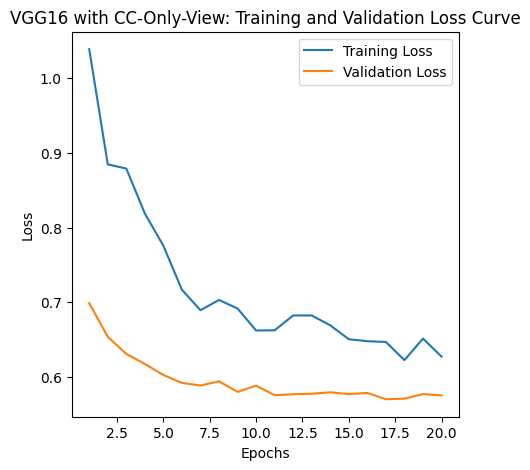

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16_cc.history, 'VGG16', 'CC-Only-View')

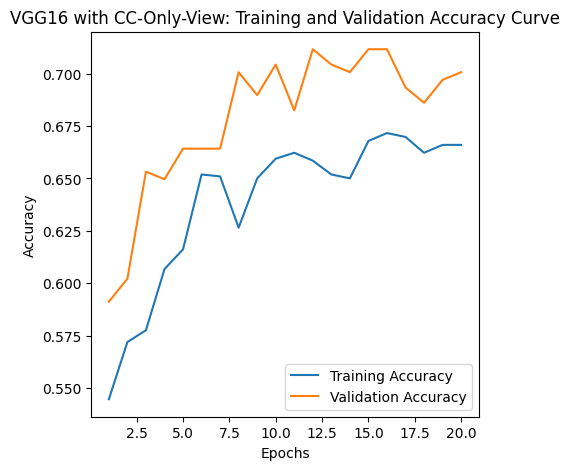

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(vgg16_cc.history, 'VGG16', 'CC-Only-View')

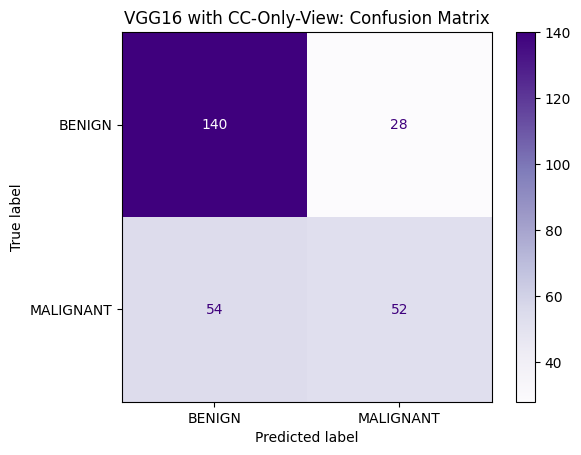

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_cc, predictions_vgg16_cc, 'VGG16', 'CC-Only-View')

### ResNet50

In [ ]:
# Select the ResNet50 model
resnet50_model_cc = select_model('resnet50')
# Compile and train the ResNet50 model with training data
resnet50_cc, train_time_resnet50_cc, peak_memory_resnet50_cc = train_selected_model(resnet50_model_cc,
                                                                                    train_dataset_cc,
                                                                                    val_dataset_cc,
                                                                                    EXPERIMENTAL_EPOCHS,
                                                                                    early_stopping,
                                                                                    class_weights_dict_cc)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 28s 548ms/step - accuracy: 0.5795 - auc: 0.5545 - loss: 0.7421 - precision: 0.4649 - recall: 0.3759 - val_accuracy: 0.6679 - val_auc: 0.6553 - val_loss: 0.6096 - val_precision: 0.6119 - val_recall: 0.3868
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 485ms/step - accuracy: 0.6397 - auc: 0.6315 - loss: 0.6676 - precision: 0.5562 - recall: 0.4681 - val_accuracy: 0.6679 - val_auc: 0.6471 - val_loss: 0.5730 - val_precision: 0.6923 - val_recall: 0.2547
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 482ms/step - accuracy: 0.6604 - auc: 0.6702 - loss: 0.6294 - precision: 0.5939 - recall: 0.4634 - val_accuracy: 0.6861 - val_auc: 0.6929 - val_loss: 0.5727 - val_precision: 0.6613 - val_recall: 0.3868
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 22s 509ms/step - accuracy: 0.6783 - auc: 0.6836 - loss: 0.6135 - precision: 0.6319 - recall: 0.4586 - val_accuracy: 0.7117 - val_auc: 0.6903 - val_loss: 0.5604 - val_precision: 0.736

In [ ]:
# Predictions and evaluations using the trained ResNet50 model
logits_resnet50_cc, predictions_resnet50_cc, metrics_dict_resnet50_cc, infer_time_resnet50_cc = generate_predictions_and_evaluations(resnet50_cc,
                                                                                                                                     val_dataset_cc,
                                                                                                                                     val_true_labels_cc,
                                                                                                                                     PREDICTION_THRESHOLD)

9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 497ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 260ms/step - accuracy: 0.7409 - auc: 0.7463 - loss: 0.5156 - precision: 0.7778 - recall: 0.4623


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
resnet50_cc_results_df = generate_results_metrics_df(
    model_name='ResNet50',
    experimental_value='CC-Only-View',
    eval_metrics=metrics_dict_resnet50_cc,
    train_time=train_time_resnet50_cc,
    infer_time=infer_time_resnet50_cc,
    peak_memory=peak_memory_resnet50_cc,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, resnet50_cc_results_df, 'views')

Stored results for 0    CC-Only-View
Name: view_type, dtype: object views


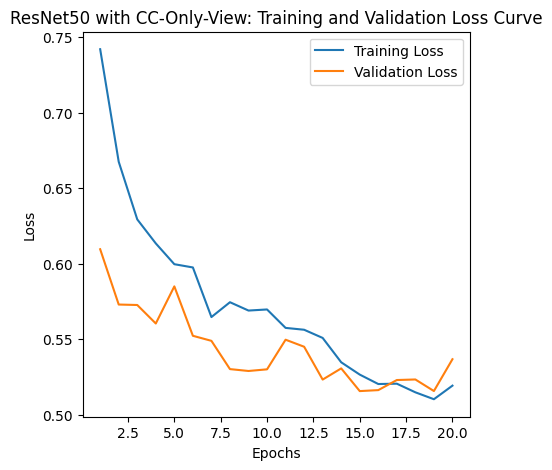

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50_cc.history, 'ResNet50', 'CC-Only-View')

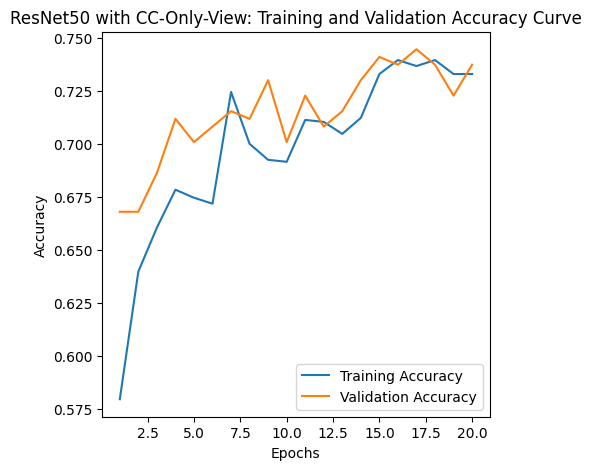

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(resnet50_cc.history, 'ResNet50', 'CC-Only-View')

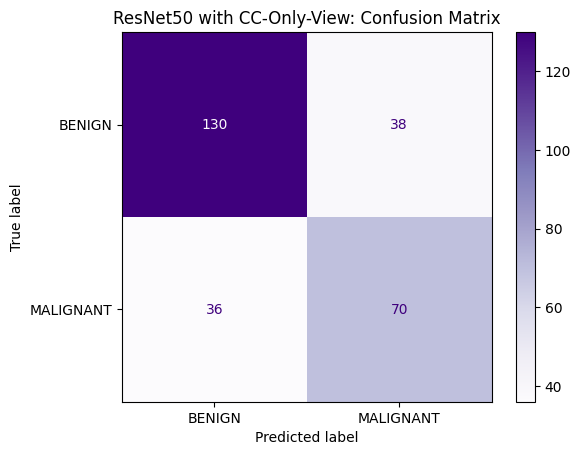

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_cc, predictions_resnet50_cc, 'ResNet50', 'CC-Only-View')

### DenseNet121

In [ ]:
# Select the DenseNet121 model
densenet121_model_cc = select_model('densenet121')
# Compile and train the DenseNet121 model with training data
densenet121_cc, train_time_densenet121_cc, peak_memory_densenet121_cc = train_selected_model(densenet121_model_cc,
                                                                                             train_dataset_cc,
                                                                                             val_dataset_cc,
                                                                                             EXPERIMENTAL_EPOCHS,
                                                                                             early_stopping,
                                                                                             class_weights_dict_cc)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 37s 641ms/step - accuracy: 0.5334 - auc: 0.5126 - loss: 1.4817 - precision: 0.4215 - recall: 0.4634 - val_accuracy: 0.6131 - val_auc: 0.5593 - val_loss: 0.7175 - val_precision: 0.5000 - val_recall: 0.2264
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 489ms/step - accuracy: 0.5607 - auc: 0.5433 - loss: 1.2143 - precision: 0.4466 - recall: 0.4350 - val_accuracy: 0.6241 - val_auc: 0.5942 - val_loss: 0.7996 - val_precision: 0.5200 - val_recall: 0.3679
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 492ms/step - accuracy: 0.5569 - auc: 0.5523 - loss: 1.2242 - precision: 0.4420 - recall: 0.4326 - val_accuracy: 0.6058 - val_auc: 0.5362 - val_loss: 0.7004 - val_precision: 0.4722 - val_recall: 0.1604
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 515ms/step - accuracy: 0.5833 - auc: 0.5678 - loss: 0.9903 - precision: 0.4730 - recall: 0.4137 - val_accuracy: 0.6314 - val_auc: 0.5714 - val_loss: 0.6668 - val_precision: 0.567

In [ ]:
# Predictions and evaluations using the trained DenseNet121 model
logits_densenet121_cc, predictions_densenet121_cc, metrics_dict_densenet121_cc, infer_time_densenet121_cc = generate_predictions_and_evaluations(densenet121_cc,
                                                                                                                                                 val_dataset_cc,
                                                                                                                                                 val_true_labels_cc,
                                                                                                                                                 PREDICTION_THRESHOLD)

9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 626ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - accuracy: 0.6131 - auc: 0.5593 - loss: 0.7175 - precision: 0.5000 - recall: 0.2264


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
densenet121_cc_results_df = generate_results_metrics_df(
    model_name='DenseNet121',
    experimental_value='CC-Only-View',
    eval_metrics=metrics_dict_densenet121_cc,
    train_time=train_time_densenet121_cc,
    infer_time=infer_time_densenet121_cc,
    peak_memory=peak_memory_densenet121_cc,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, densenet121_cc_results_df, 'views')

Stored results for 0    CC-Only-View
Name: view_type, dtype: object views


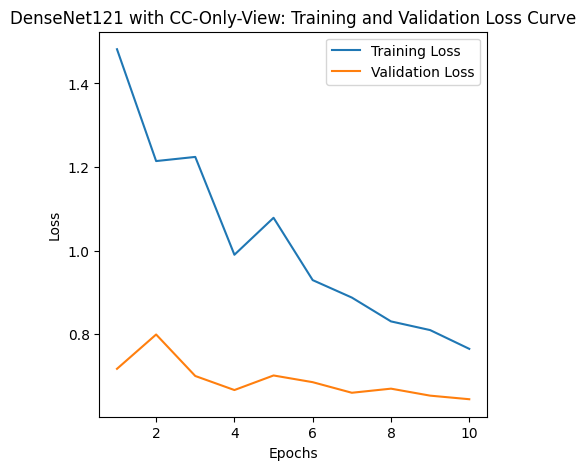

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121_cc.history, 'DenseNet121', 'CC-Only-View')

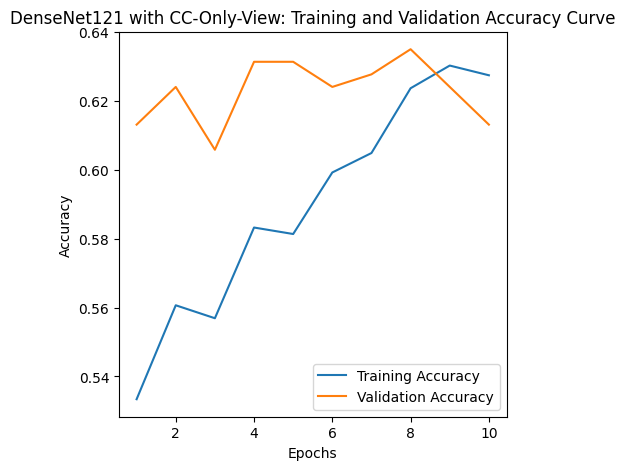

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(densenet121_cc.history, 'DenseNet121', 'CC-Only-View')

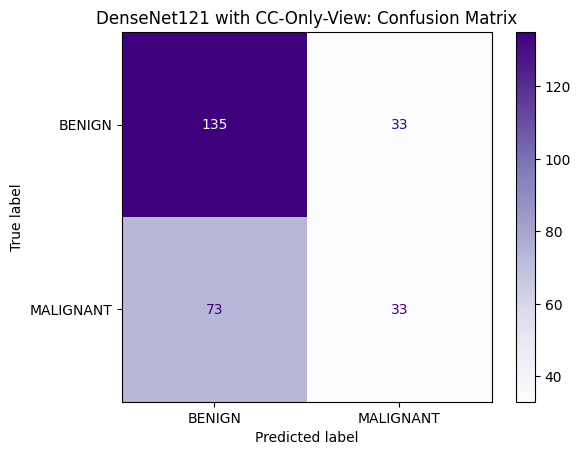

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_cc, predictions_densenet121_cc, 'DenseNet121', 'CC-Only-View')

### MobileNetV2

In [ ]:
# Select the MobileNetV2 model
mobilenetv2_model_cc = select_model('mobilenetv2')
# Compile and train the MobileNetV2 model with training data
mobilenetv2_cc, train_time_mobilenetv2_cc, peak_memory_mobilenetv2_cc = train_selected_model(mobilenetv2_model_cc,
                                                                                             train_dataset_cc,
                                                                                             val_dataset_cc,
                                                                                             EXPERIMENTAL_EPOCHS,
                                                                                             early_stopping,
                                                                                             class_weights_dict_cc)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 465ms/step - accuracy: 0.5456 - auc: 0.5226 - loss: 0.7650 - precision: 0.4051 - recall: 0.3026 - val_accuracy: 0.6277 - val_auc: 0.5779 - val_loss: 0.6585 - val_precision: 0.6429 - val_recall: 0.0849
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 414ms/step - accuracy: 0.5776 - auc: 0.5619 - loss: 0.7266 - precision: 0.4599 - recall: 0.3522 - val_accuracy: 0.6423 - val_auc: 0.5900 - val_loss: 0.6524 - val_precision: 0.6818 - val_recall: 0.1415
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 413ms/step - accuracy: 0.5974 - auc: 0.5774 - loss: 0.7095 - precision: 0.4906 - recall: 0.3073 - val_accuracy: 0.6314 - val_auc: 0.5588 - val_loss: 0.6439 - val_precision: 0.8571 - val_recall: 0.0566
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 416ms/step - accuracy: 0.5898 - auc: 0.5632 - loss: 0.7046 - precision: 0.4780 - recall: 0.3333 - val_accuracy: 0.6423 - val_auc: 0.6385 - val_loss: 0.7014 - val_precision: 0.5556 

In [ ]:
# Predictions and evaluations using the trained MobileNetV2 model
logits_mobilenetv2_cc, predictions_mobilenetv2_cc, metrics_dict_mobilenetv2_cc, infer_time_mobilenetv2_cc = generate_predictions_and_evaluations(mobilenetv2_cc,
                                                                                                                                                 val_dataset_cc,
                                                                                                                                                 val_true_labels_cc,
                                                                                                                                                 PREDICTION_THRESHOLD)

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 339ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 187ms/step - accuracy: 0.6277 - auc: 0.5779 - loss: 0.6585 - precision: 0.6429 - recall: 0.0849


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
mobilenetv2_cc_results_df = generate_results_metrics_df(
    model_name='MobileNetV2',
    experimental_value='CC-Only-View',
    eval_metrics=metrics_dict_mobilenetv2_cc,
    train_time=train_time_mobilenetv2_cc,
    infer_time=infer_time_mobilenetv2_cc,
    peak_memory=peak_memory_mobilenetv2_cc,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, mobilenetv2_cc_results_df, 'views')

Stored results for 0    CC-Only-View
Name: view_type, dtype: object views


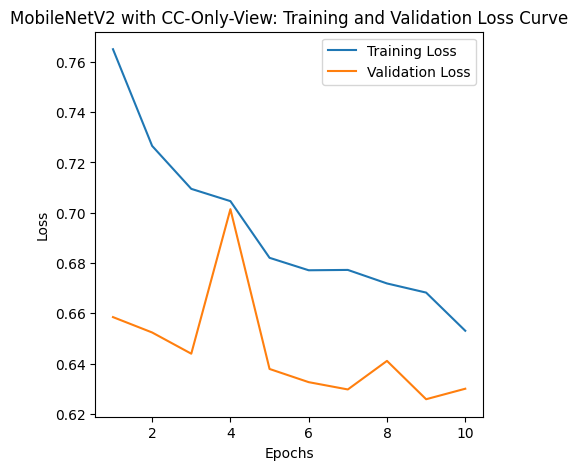

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2_cc.history, 'MobileNetV2', 'CC-Only-View')

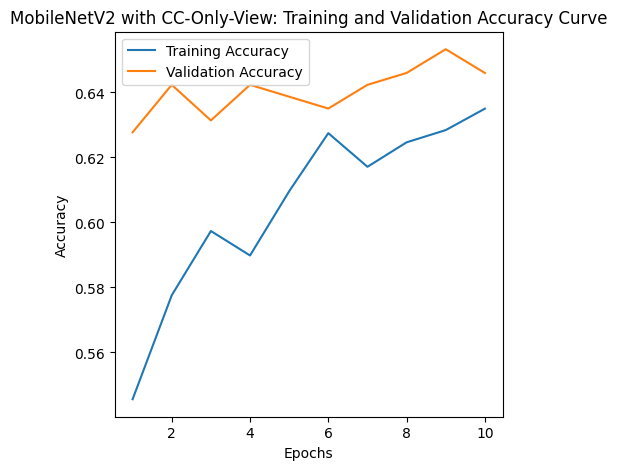

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(mobilenetv2_cc.history, 'MobileNetV2', 'CC-Only-View')

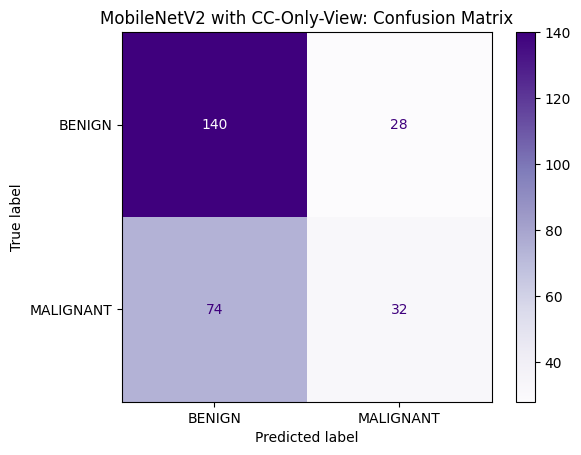

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_cc, predictions_mobilenetv2_cc, 'MobileNetV2', 'CC-Only-View')

### EfficientNet-B0

In [ ]:
# Select the EfficientNet-B0 model
efficientnetb0_model_cc = select_model('efficientnetb0')
# Compile and train the EfficientNet-B0 model with training data
efficientnetb0_cc, train_time_efficientnetb0_cc, peak_memory_efficientnetb0_cc = train_selected_model(efficientnetb0_model_cc,
                                                                                                      train_dataset_cc,
                                                                                                      val_dataset_cc,
                                                                                                      EXPERIMENTAL_EPOCHS,
                                                                                                      early_stopping,
                                                                                                      class_weights_dict_cc)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 31s 536ms/step - accuracy: 0.6199 - auc: 0.6035 - loss: 0.6684 - precision: 0.5646 - recall: 0.1962 - val_accuracy: 0.6606 - val_auc: 0.6695 - val_loss: 0.6107 - val_precision: 0.6512 - val_recall: 0.2642
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 38s 437ms/step - accuracy: 0.6453 - auc: 0.6579 - loss: 0.6339 - precision: 0.5958 - recall: 0.3381 - val_accuracy: 0.6533 - val_auc: 0.7279 - val_loss: 0.6331 - val_precision: 0.5495 - val_recall: 0.5755
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 435ms/step - accuracy: 0.6623 - auc: 0.6782 - loss: 0.6237 - precision: 0.6168 - recall: 0.3995 - val_accuracy: 0.6752 - val_auc: 0.7015 - val_loss: 0.5969 - val_precision: 0.6164 - val_recall: 0.4245
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 440ms/step - accuracy: 0.6642 - auc: 0.6958 - loss: 0.6083 - precision: 0.6086 - recall: 0.4374 - val_accuracy: 0.6861 - val_auc: 0.6842 - val_loss: 0.5848 - val_precision: 0.656

In [ ]:
# Predictions and evaluations using the trained EfficientNet-B0 model
logits_efficientnetb0_cc, predictions_efficientnetb0_cc, metrics_dict_efficientnetb0_cc, infer_time_efficientnetb0_cc = generate_predictions_and_evaluations(
                                                                                                                               efficientnetb0_cc,
                                                                                                                               val_dataset_cc,
                                                                                                                               val_true_labels_cc,
                                                                                                                               PREDICTION_THRESHOLD)

9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 419ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.6606 - auc: 0.6695 - loss: 0.6107 - precision: 0.6512 - recall: 0.2642


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
efficientnetb0_cc_results_df = generate_results_metrics_df(
    model_name='EfficientNet-B0',
    experimental_value='CC-Only-View',
    eval_metrics=metrics_dict_efficientnetb0_cc,
    train_time=train_time_efficientnetb0_cc,
    infer_time=infer_time_efficientnetb0_cc,
    peak_memory=peak_memory_efficientnetb0_cc,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, efficientnetb0_cc_results_df, 'views')

Stored results for 0    CC-Only-View
Name: view_type, dtype: object views


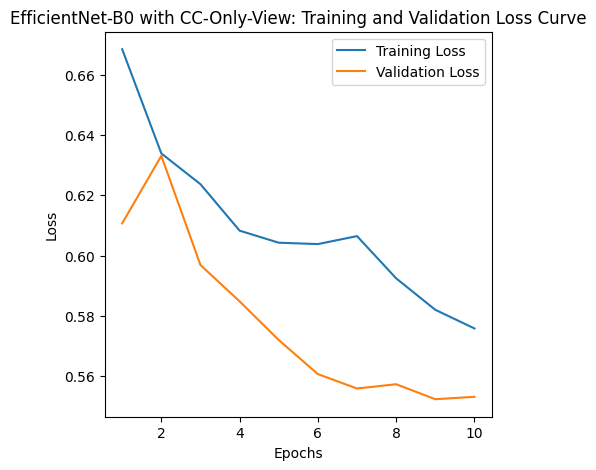

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0_cc.history, 'EfficientNet-B0', 'CC-Only-View')

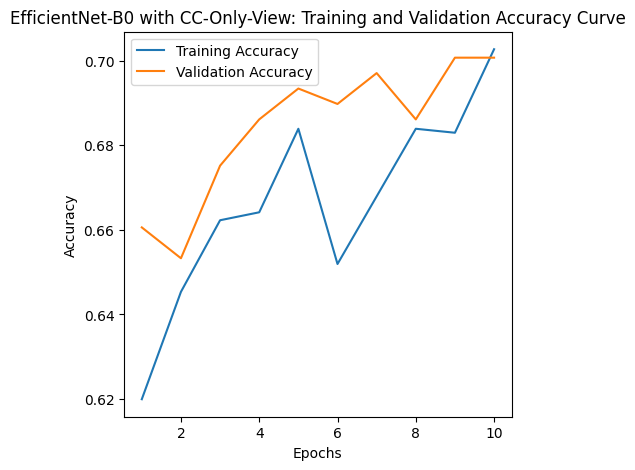

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(efficientnetb0_cc.history, 'EfficientNet-B0', 'CC-Only-View')

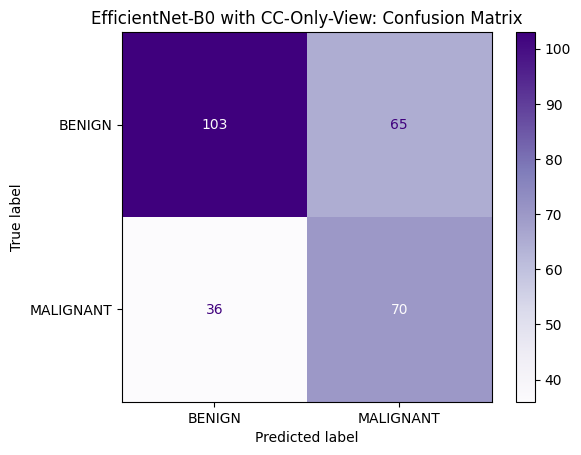

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_cc, predictions_efficientnetb0_cc, 'EfficientNet-B0', 'CC-Only-View')

## MLO view only Experiment

#### tf.data Datasets for MLO-only View

In [ ]:
# Generate training and validation datasets for MLO only
train_dataset_mlo = dataset_preparation(train_df_mlo, baseline_preprocessor, BUFFER_SIZE_MLO, BATCH_SIZE, training=True)
val_dataset_mlo = dataset_preparation(val_df_mlo, baseline_preprocessor, BUFFER_SIZE_MLO, BATCH_SIZE, training=False)

### VGG16

In [ ]:
# Select the VGG16 model
vgg16_model_mlo = select_model('vgg16')
# Compile and train the VGG16 model with training data
vgg16_mlo, train_time_vgg16_mlo, peak_memory_vgg16_mlo = train_selected_model(vgg16_model_mlo,
                                                                              train_dataset_mlo,
                                                                              val_dataset_mlo,
                                                                              EXPERIMENTAL_EPOCHS,
                                                                              early_stopping,
                                                                              class_weights_dict_mlo)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 493ms/step - accuracy: 0.5066 - auc: 0.5059 - loss: 1.0578 - precision: 0.3938 - recall: 0.4511 - val_accuracy: 0.6038 - val_auc: 0.5650 - val_loss: 0.6905 - val_precision: 0.5000 - val_recall: 0.2177
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 492ms/step - accuracy: 0.5734 - auc: 0.5587 - loss: 0.8731 - precision: 0.4604 - recall: 0.4345 - val_accuracy: 0.6262 - val_auc: 0.5896 - val_loss: 0.6747 - val_precision: 0.5455 - val_recall: 0.3387
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 471ms/step - accuracy: 0.5875 - auc: 0.5788 - loss: 0.8224 - precision: 0.4790 - recall: 0.4511 - val_accuracy: 0.6358 - val_auc: 0.5993 - val_loss: 0.6527 - val_precision: 0.5926 - val_recall: 0.2581
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 491ms/step - accuracy: 0.5990 - auc: 0.5920 - loss: 0.7991 - precision: 0.4946 - recall: 0.4761 - val_accuracy: 0.6294 - val_auc: 0.5802 - val_loss: 0.6388 - val_precision: 0.611

In [ ]:
# Predictions and evaluations using the trained VGG16 model
logits_vgg16_mlo, predictions_vgg16_mlo, metrics_dict_vgg16_mlo, infer_time_vgg16_mlo = generate_predictions_and_evaluations(vgg16_mlo,
                                                                                                                             val_dataset_mlo,
                                                                                                                             val_true_labels_mlo,
                                                                                                                             PREDICTION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 242ms/step - accuracy: 0.6454 - auc: 0.6359 - loss: 0.5998 - precision: 0.6857 - recall: 0.1935


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
vgg16_mlo_results_df = generate_results_metrics_df(
    model_name='VGG16',
    experimental_value='MLO-Only-View',
    eval_metrics=metrics_dict_vgg16_mlo,
    train_time=train_time_vgg16_mlo,
    infer_time=infer_time_vgg16_mlo,
    peak_memory=peak_memory_vgg16_mlo,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, vgg16_mlo_results_df, 'views')

Stored results for 0    MLO-Only-View
Name: view_type, dtype: object views


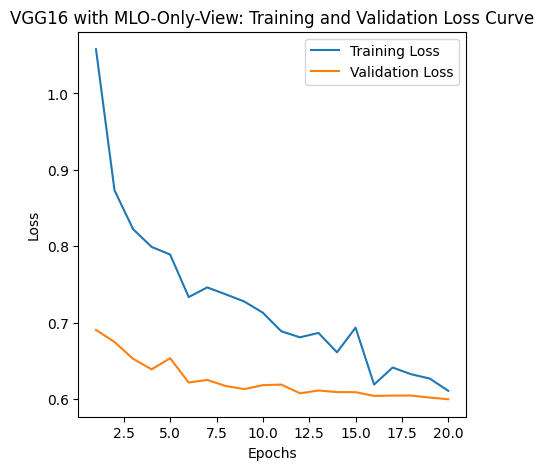

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16_mlo.history, 'VGG16', 'MLO-Only-View')

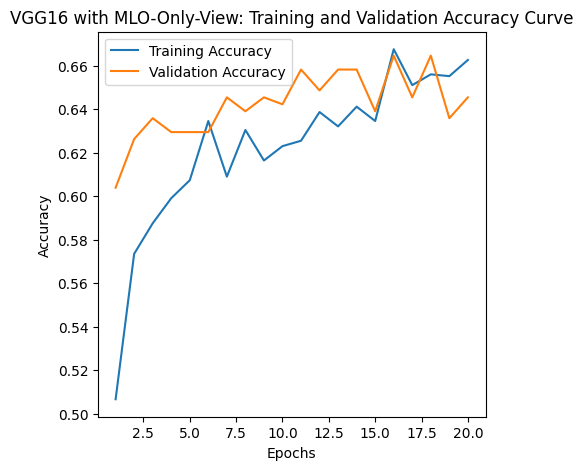

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(vgg16_mlo.history, 'VGG16', 'MLO-Only-View')

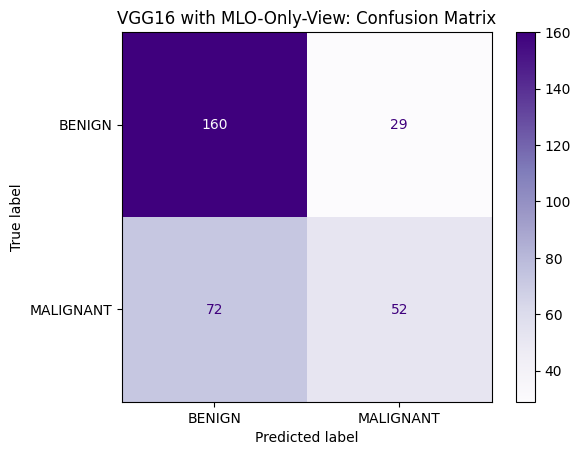

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_mlo, predictions_vgg16_mlo, 'VGG16', 'MLO-Only-View')

### ResNet50

In [ ]:
# Select the ResNet50 model
resnet50_model_mlo = select_model('resnet50')
# Compile and train the ResNet50 model with training data
resnet50_mlo, train_time_resnet50_mlo, peak_memory_resnet50_mlo = train_selected_model(resnet50_model_mlo,
                                                                                       train_dataset_mlo,
                                                                                       val_dataset_mlo,
                                                                                       EXPERIMENTAL_EPOCHS,
                                                                                       early_stopping,
                                                                                       class_weights_dict_mlo)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 540ms/step - accuracy: 0.5899 - auc: 0.5878 - loss: 0.7014 - precision: 0.4789 - recall: 0.3784 - val_accuracy: 0.6581 - val_auc: 0.6295 - val_loss: 0.6287 - val_precision: 0.7742 - val_recall: 0.1935
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 468ms/step - accuracy: 0.6411 - auc: 0.6344 - loss: 0.6566 - precision: 0.5628 - recall: 0.4283 - val_accuracy: 0.6741 - val_auc: 0.6615 - val_loss: 0.6231 - val_precision: 0.6250 - val_recall: 0.4435
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 482ms/step - accuracy: 0.6419 - auc: 0.6457 - loss: 0.6332 - precision: 0.5598 - recall: 0.4574 - val_accuracy: 0.6773 - val_auc: 0.6636 - val_loss: 0.6060 - val_precision: 0.6885 - val_recall: 0.3387
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 472ms/step - accuracy: 0.6485 - auc: 0.6507 - loss: 0.6328 - precision: 0.5679 - recall: 0.4782 - val_accuracy: 0.6581 - val_auc: 0.6375 - val_loss: 0.5988 - val_precision: 0.814

In [ ]:
# Predictions and evaluations using the trained ResNet50 model
logits_resnet50_mlo, predictions_resnet50_mlo, metrics_dict_resnet50_mlo, infer_time_resnet50_mlo = generate_predictions_and_evaluations(resnet50_mlo,
                                                                                                                                         val_dataset_mlo,
                                                                                                                                         val_true_labels_mlo,
                                                                                                                                         PREDICTION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 407ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 239ms/step - accuracy: 0.6837 - auc: 0.6657 - loss: 0.5685 - precision: 0.7451 - recall: 0.3065


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
resnet50_mlo_results_df = generate_results_metrics_df(
    model_name='ResNet50',
    experimental_value='MLO-Only-View',
    eval_metrics=metrics_dict_resnet50_mlo,
    train_time=train_time_resnet50_mlo,
    infer_time=infer_time_resnet50_mlo,
    peak_memory=peak_memory_resnet50_mlo,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, resnet50_mlo_results_df, 'views')

Stored results for 0    MLO-Only-View
Name: view_type, dtype: object views


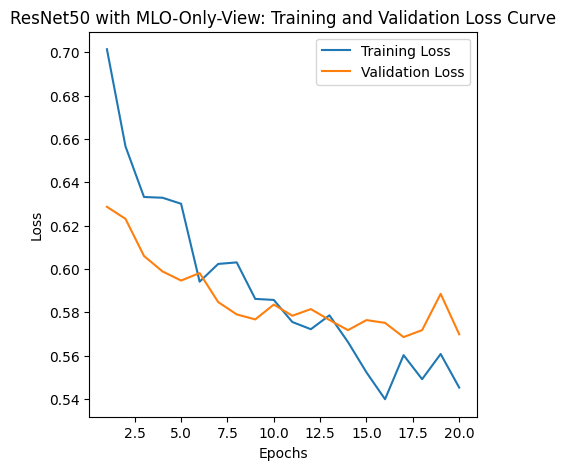

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50_mlo.history, 'ResNet50', 'MLO-Only-View')

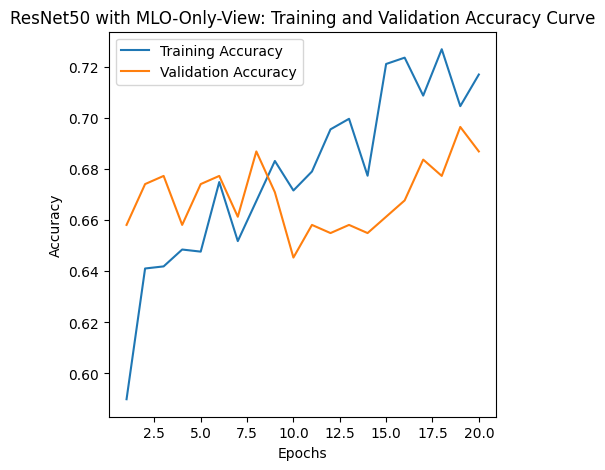

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(resnet50_mlo.history, 'ResNet50', 'MLO-Only-View')

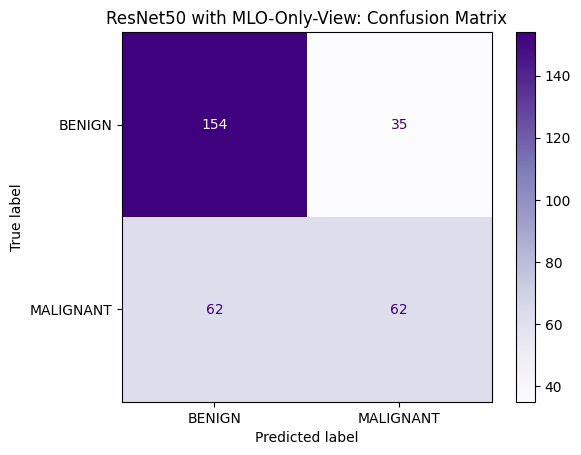

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_mlo, predictions_resnet50_mlo, 'ResNet50', 'MLO-Only-View')

### DenseNet121

In [ ]:
# Select the DenseNet121 model
densenet121_model_mlo = select_model('densenet121')
# Compile and train the DenseNet121 model with training data
densenet121_mlo, train_time_densenet121_mlo, peak_memory_densenet121_mlo = train_selected_model(densenet121_model_mlo,
                                                                                                train_dataset_mlo,
                                                                                                val_dataset_mlo,
                                                                                                EXPERIMENTAL_EPOCHS,
                                                                                                early_stopping,
                                                                                                class_weights_dict_mlo)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 38s 622ms/step - accuracy: 0.5099 - auc: 0.4913 - loss: 1.4884 - precision: 0.3859 - recall: 0.3971 - val_accuracy: 0.6102 - val_auc: 0.5677 - val_loss: 0.7066 - val_precision: 0.5139 - val_recall: 0.2984
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 504ms/step - accuracy: 0.5528 - auc: 0.5380 - loss: 1.2002 - precision: 0.4381 - recall: 0.4491 - val_accuracy: 0.6422 - val_auc: 0.5859 - val_loss: 0.6819 - val_precision: 0.6000 - val_recall: 0.2903
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 480ms/step - accuracy: 0.5924 - auc: 0.5737 - loss: 1.0785 - precision: 0.4851 - recall: 0.4407 - val_accuracy: 0.6294 - val_auc: 0.6034 - val_loss: 0.6723 - val_precision: 0.5606 - val_recall: 0.2984
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 498ms/step - accuracy: 0.5883 - auc: 0.5740 - loss: 1.0020 - precision: 0.4789 - recall: 0.4241 - val_accuracy: 0.6198 - val_auc: 0.6147 - val_loss: 0.7338 - val_precision: 0.521

In [ ]:
# Predictions and evaluations using the trained DenseNet121 model
logits_densenet121_mlo, predictions_densenet121_mlo, metrics_dict_densenet121_mlo, infer_time_densenet121_mlo = generate_predictions_and_evaluations(densenet121_mlo,
                                                                                                                                                     val_dataset_mlo,
                                                                                                                                                     val_true_labels_mlo,
                                                                                                                                                     PREDICTION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 637ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step - accuracy: 0.6102 - auc: 0.5677 - loss: 0.7066 - precision: 0.5139 - recall: 0.2984


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
densenet121_mlo_results_df = generate_results_metrics_df(
    model_name='DenseNet121',
    experimental_value='MLO-Only-View',
    eval_metrics=metrics_dict_densenet121_mlo,
    train_time=train_time_densenet121_mlo,
    infer_time=infer_time_densenet121_mlo,
    peak_memory=peak_memory_densenet121_mlo,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, densenet121_mlo_results_df, 'views')

Stored results for 0    MLO-Only-View
Name: view_type, dtype: object views


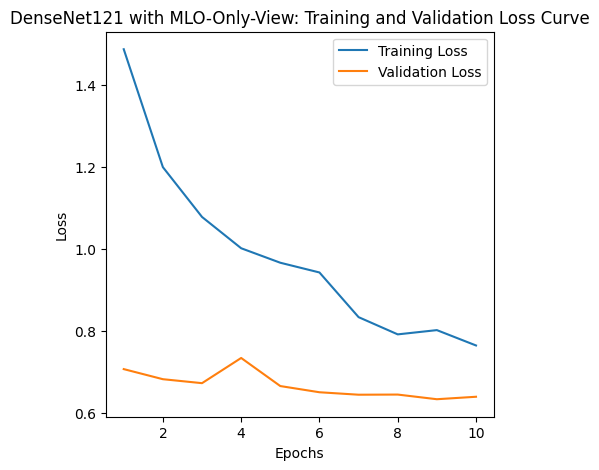

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121_mlo.history, 'DenseNet121', 'MLO-Only-View')

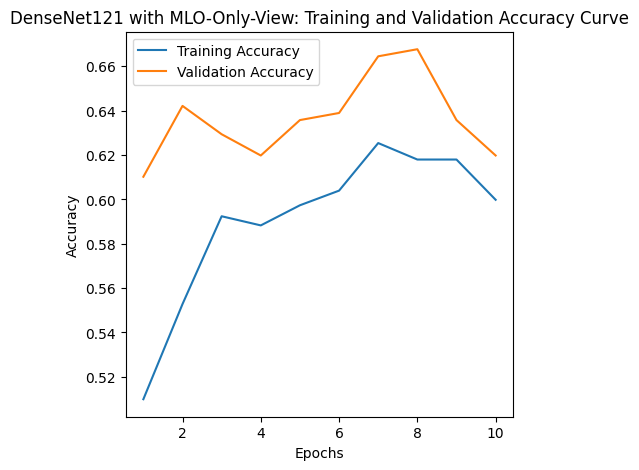

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(densenet121_mlo.history, 'DenseNet121', 'MLO-Only-View')

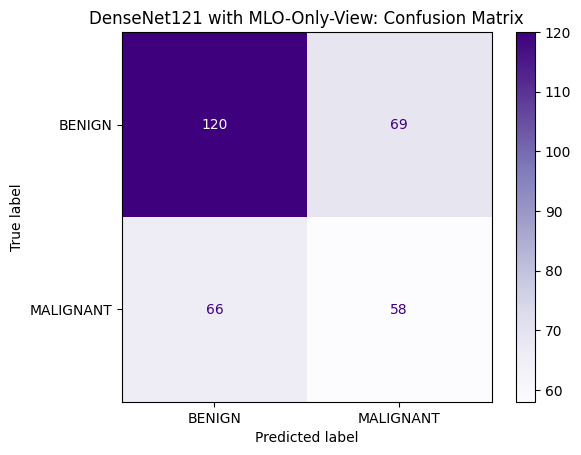

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_mlo, predictions_densenet121_mlo, 'DenseNet121', 'MLO-Only-View')

### MobileNetV2

In [ ]:
# Select the MobileNetV2 model
mobilenetv2_model_mlo = select_model('mobilenetv2')
# Compile and train the MobileNetV2 model with training data
mobilenetv2_mlo, train_time_mobilenetv2_mlo, peak_memory_mobilenetv2_mlo = train_selected_model(mobilenetv2_model_mlo,
                                                                                                train_dataset_mlo,
                                                                                                val_dataset_mlo,
                                                                                                EXPERIMENTAL_EPOCHS,
                                                                                                early_stopping,
                                                                                                class_weights_dict_mlo)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 25s 484ms/step - accuracy: 0.5338 - auc: 0.4999 - loss: 0.7896 - precision: 0.3895 - recall: 0.3077 - val_accuracy: 0.6102 - val_auc: 0.5948 - val_loss: 0.7207 - val_precision: 0.5139 - val_recall: 0.2984
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 427ms/step - accuracy: 0.6147 - auc: 0.5844 - loss: 0.7063 - precision: 0.5208 - recall: 0.3638 - val_accuracy: 0.6326 - val_auc: 0.5684 - val_loss: 0.6505 - val_precision: 0.8462 - val_recall: 0.0887
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 423ms/step - accuracy: 0.6048 - auc: 0.5762 - loss: 0.7140 - precision: 0.5031 - recall: 0.3410 - val_accuracy: 0.6230 - val_auc: 0.5533 - val_loss: 0.6460 - val_precision: 0.8000 - val_recall: 0.0645
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 413ms/step - accuracy: 0.6064 - auc: 0.6063 - loss: 0.6890 - precision: 0.5059 - recall: 0.3555 - val_accuracy: 0.6230 - val_auc: 0.6004 - val_loss: 0.6715 - val_precision: 0.6154 

In [ ]:
# Predictions and evaluations using the trained MobileNetV2 model
logits_mobilenetv2_mlo, predictions_mobilenetv2_mlo, metrics_dict_mobilenetv2_mlo, infer_time_mobilenetv2_mlo = generate_predictions_and_evaluations(mobilenetv2_mlo,
                                                                                                                                                     val_dataset_mlo,
                                                                                                                                                     val_true_labels_mlo,
                                                                                                                                                     PREDICTION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 305ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.6102 - auc: 0.5948 - loss: 0.7207 - precision: 0.5139 - recall: 0.2984


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
mobilenetv2_mlo_results_df = generate_results_metrics_df(
    model_name='MobileNetV2',
    experimental_value='MLO-Only-View',
    eval_metrics=metrics_dict_mobilenetv2_mlo,
    train_time=train_time_mobilenetv2_mlo,
    infer_time=infer_time_mobilenetv2_mlo,
    peak_memory=peak_memory_mobilenetv2_mlo,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, mobilenetv2_mlo_results_df, 'views')

Stored results for 0    MLO-Only-View
Name: view_type, dtype: object views


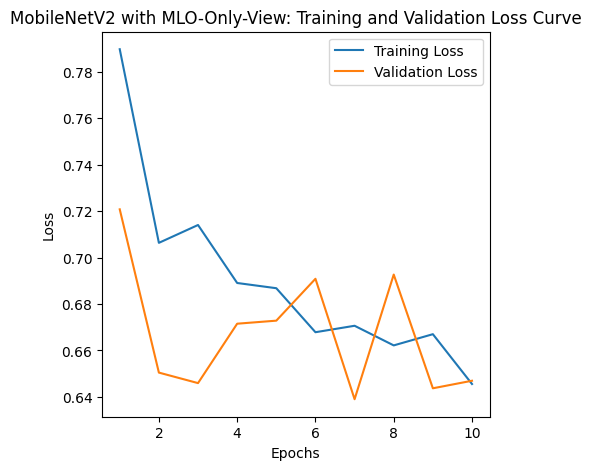

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2_mlo.history, 'MobileNetV2', 'MLO-Only-View')

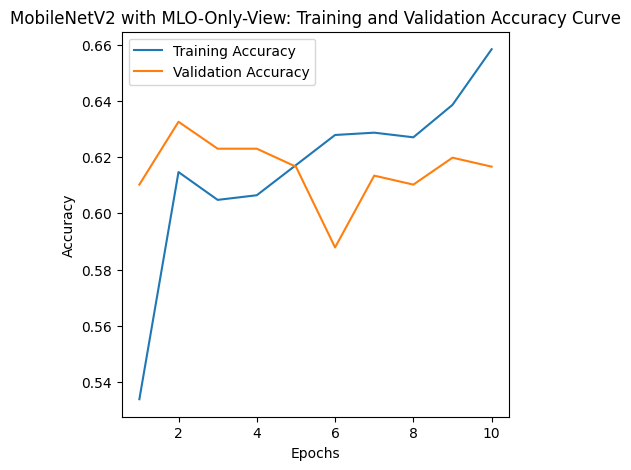

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(mobilenetv2_mlo.history, 'MobileNetV2', 'MLO-Only-View')

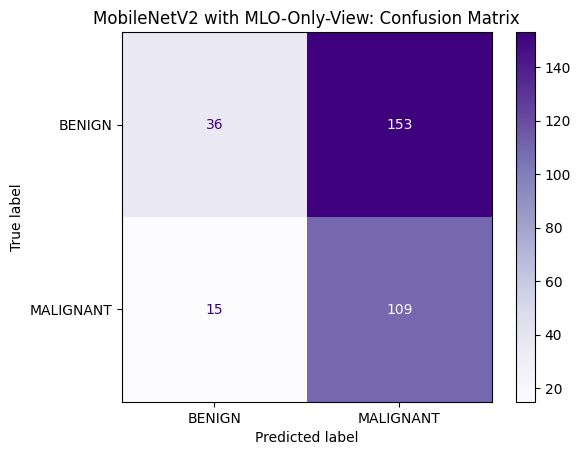

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_mlo, predictions_mobilenetv2_mlo, 'MobileNetV2', 'MLO-Only-View')

### EfficientNet-B0

In [ ]:
# Select the EfficientNet-B0 model
efficientnetb0_model_mlo = select_model('efficientnetb0')
# Compile and train the EfficientNet-B0 model with training data
efficientnetb0_mlo, train_time_efficientnetb0_mlo, peak_memory_efficientnetb0_mlo = train_selected_model(efficientnetb0_model_mlo,
                                                                                                         train_dataset_mlo,
                                                                                                         val_dataset_mlo,
                                                                                                         EXPERIMENTAL_EPOCHS,
                                                                                                         early_stopping,
                                                                                                         class_weights_dict_mlo)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 523ms/step - accuracy: 0.6073 - auc: 0.5745 - loss: 0.6798 - precision: 0.5172 - recall: 0.1559 - val_accuracy: 0.6294 - val_auc: 0.6281 - val_loss: 0.6346 - val_precision: 0.8333 - val_recall: 0.0806
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 464ms/step - accuracy: 0.6535 - auc: 0.6740 - loss: 0.6318 - precision: 0.6093 - recall: 0.3534 - val_accuracy: 0.6358 - val_auc: 0.6319 - val_loss: 0.6287 - val_precision: 0.5758 - val_recall: 0.3065
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 441ms/step - accuracy: 0.6625 - auc: 0.6804 - loss: 0.6219 - precision: 0.6440 - recall: 0.3347 - val_accuracy: 0.6677 - val_auc: 0.6526 - val_loss: 0.6229 - val_precision: 0.6351 - val_recall: 0.3790
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 447ms/step - accuracy: 0.6832 - auc: 0.6778 - loss: 0.6179 - precision: 0.6751 - recall: 0.3888 - val_accuracy: 0.6486 - val_auc: 0.6756 - val_loss: 0.6360 - val_precision: 0.571

In [ ]:
# Predictions and evaluations using the trained EfficientNet-B0 model
logits_efficientnetb0_mlo, predictions_efficientnetb0_mlo, metrics_dict_efficientnetb0_mlo, infer_time_efficientnetb0_mlo = generate_predictions_and_evaluations(
                                                                                                                                       efficientnetb0_mlo,
                                                                                                                                       val_dataset_mlo,
                                                                                                                                       val_true_labels_mlo,
                                                                                                                                       PREDICTION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 459ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 0.6294 - auc: 0.6281 - loss: 0.6346 - precision: 0.8333 - recall: 0.0806


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
efficientnetb0_mlo_results_df = generate_results_metrics_df(
    model_name='EfficientNet-B0',
    experimental_value='MLO-Only-View',
    eval_metrics=metrics_dict_efficientnetb0_mlo,
    train_time=train_time_efficientnetb0_mlo,
    infer_time=infer_time_efficientnetb0_mlo,
    peak_memory=peak_memory_efficientnetb0_mlo,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, efficientnetb0_mlo_results_df, 'views')

Stored results for 0    MLO-Only-View
Name: view_type, dtype: object views


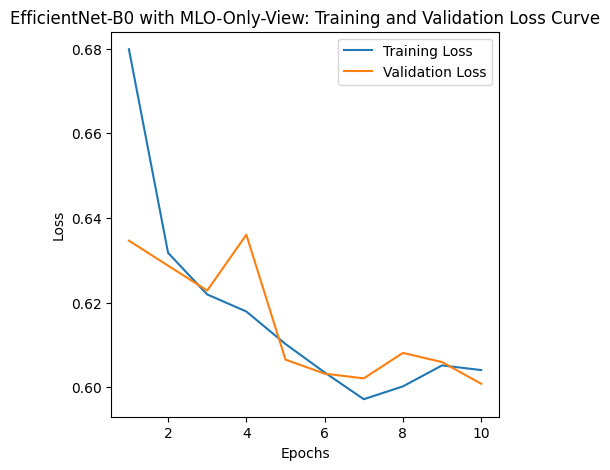

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0_mlo.history, 'EfficientNet-B0', 'MLO-Only-View')

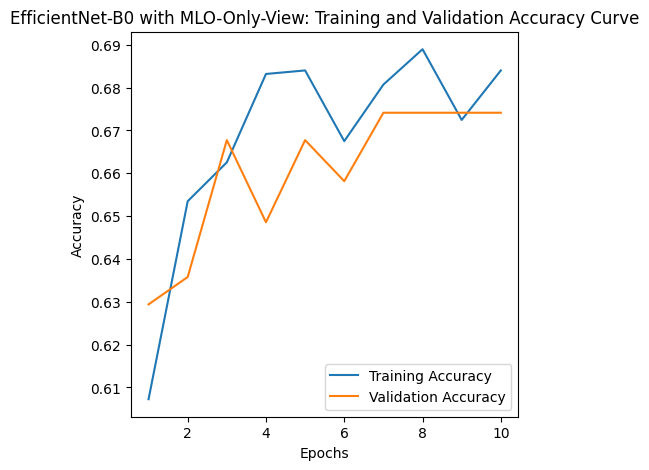

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(efficientnetb0_mlo.history, 'EfficientNet-B0', 'MLO-Only-View')

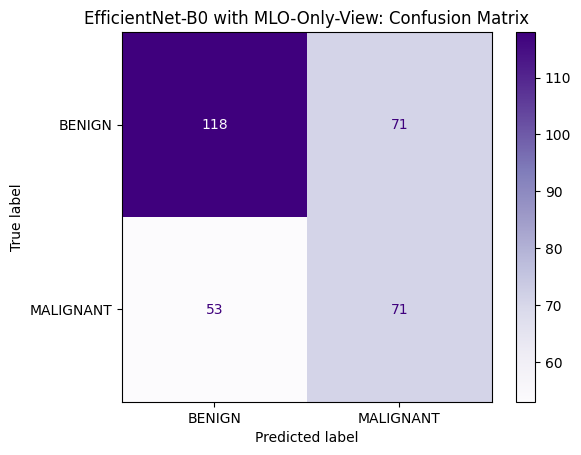

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels_mlo, predictions_efficientnetb0_mlo, 'EfficientNet-B0', 'MLO-Only-View')